# 3 Analysis of the Coverage of the Protospacer Sequences Found in NGS PCR Samples PD 
Helen King


Work with Grazi Vieria

<img src="../files/flowthrough.png " width="400"/>



Using the cloning statedgy above and found in Replogle et al. This notebook analyses the RNA sequencing results of two different PCR experiments. To do so, we have run pcr_analyze_coverage_protospacer.sh to process fastq.gz to coverage files that are both specific to the protospacer loci. The 171bp samples cover protospacerC (also labeled PS1) in the final steps. The 164bp samples cover protospacerD (also labeled PS2) in the final steps.

<img src="../files/PCR_scripts_flowthrough.png" width="300"/>


Plasmid samples are the plasmid pool grazi created. 

gDNA samples were extracted from the CRISPRi HPSCs  after they were transduced using the lentiviral pool generated from the plasmid



| Sample_Name     | Forward Primer | Reverse Primer | Coordinates | Protospacer Sequence of Interest  |
| --------------- | -------------- | -------------- | ----------- | --------------------------------- |
| Plasmid_mU6_704 | mU6            | 704            | 79-99       | PS1                               |
| Plasmid_LKO_705 | LKO            | 705            | 84-103      | PS2                               |
| gDNA_LKO_705    | LKO            | 705            | 84-103      | PS2                               |
| gDNA_mU6_704    | mUG            | 704            | 79-99       | PS1                               |

![Cloning stradegy](../files/164.png "Title")
![Cloning stradegy](../files/171.png "Title")


In [1]:
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import glob # package for Unix-style pathname pattern expansion
import os   # Python operating system interface
import numpy as np


# Set the color for the histogram
color1 ='#4d00c7'
palecolor1="#b366ff"
color2= '#da3c07'
palecolor2="#ff8954"
color3='#05d3d3'
color4='#c6c7c5'
color5='black'


# Create the color palette
palette = sns.color_palette([palecolor1, palecolor2, color3, color4])
def plot_protospacers(df, sample, plasmid, pilotstudy_list, x_axis="Basepair", y_axis="Coverage", hue="Protospacer", limits=(0,200)):
    #Subset the df on the pilot study protospacer seqences describe above
    df = df [(df["Sample"]== sample )&(df["Plasmid"]== plasmid )].dropna()
    df=df[df["Protospacer"].str.contains('|'.join(pilotstudy_list))].dropna()
    df.reset_index()
    sns.scatterplot( x=df[x_axis], y=df[y_axis], hue=df[hue],palette=palette)
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.title("Example of Mapping For 4 Guides: "+sample+" "+plasmid)
    plt.xlim(limits)
    # plt.ylim((0,20))
    plt.show()

The directory COVERAGE contains all samtools coverage files for bam files created by samtools. This analysis will take the coverage and use it to ask two main questions.


1) What is the distribution of protospacers found in the primer pool? Is there any bias?

2) Are the surrounding sequences around protospacer 1 and 2 constant?



Found overrepresented sequences in each of the samples.
Most of the overrepresented sequences in R1/R2 should be the primer sequences. As the given fastq files provided were aberrantly demultiplexed. There was some reads with the adapter sequences still attached. Challenging as the reads with adaper sequences need to be trimmed, then the remaining mixture needs to filter out only PCR specific sequences. 

- gDNA mU6 
    - R1 - 90.31% mU6-F
    - R2 - 82.07% RW704_illuseq_rev_02
- gDNA LKO 
    - R1 - 96.30% LKO1.5'
    - R2 - 	94.31% RW705_illuSeq_Rev03
    
- Plasmid mU6  ????
    - R1 - 97.03% LKO1.5'
    - R2 - 94.21% RW705_illuSeq_Rev03
- Plasmid LKO ???
    - R1 - 96.96% LKO1.5'
    - R2 -  93.79% RW705_illuSeq_Rev03



 

In [2]:

directory = '../COVERAGE/'
# Obtain list of filenames that end in .txt in the directory
all_files = glob.glob(os.path.join(directory, "*1.coverage"))
all_files.extend(glob.glob(os.path.join(directory, "*4.coverage")))
#Append them to a df 
your_list = [ ]
for filename in all_files:
    dataframe = pd.read_csv(filename, index_col=None, header=None, sep="\t")
    dataframe["Filename"]=str(filename)
    dataframe["Protospacer_type"]=dataframe["Filename"].str.split("/").str.get(-1).str.split("-").str.get(3).str.split(".").str.get(0).str.split("_").str.get(0)
    dataframe["Protospacer_num"]=dataframe["Filename"].str.split("/").str.get(-1).str.split("-").str.get(3).str.split(".").str.get(0).str.split("_").str.get(1)
    dataframe["Protospacer_letter"]=dataframe["Filename"].str.split("/").str.get(-1).str.split("-").str.get(3).str.split(".").str.get(0).str.split("_").str.get(2)
    dataframe["Protospacer"]=np.where(dataframe["Protospacer_num"]=="negcntrl",dataframe["Protospacer_type"]+"_"+dataframe["Protospacer_letter"]+"_"+dataframe["Protospacer_num"],dataframe["Protospacer_type"]+"_"+dataframe["Protospacer_num"])
    dataframe["Filename"]=dataframe["Filename"].str.split("/").str.get(-1).str.split(".").str.get(0)
    dataframe["Sample"]=dataframe["Filename"].str.split("/").str.get(-1).str.split(".").str.get(0).str.split("-").str.get(0)
    dataframe["Plasmid"]=dataframe["Filename"].str.split("/").str.get(-1).str.split(".").str.get(0).str.split("-").str.get(1)
    your_list.append(dataframe)

PCR_DF=pd.DataFrame(pd.concat(your_list,  ignore_index=True))
PCR_DF.columns =["Plasmid_FullName", "Basepair", "Coverage", "Filename","Protospacer_type" , "Protospacer_letter","Protospacer_num" ,"Protospacer", "Sample","Plasmid"]
print(PCR_DF.head(n=2))

    Plasmid_FullName  Basepair  Coverage                           Filename  \
0  sgTOMM22_1_AB_171         1     87131  gDNA-mU6-704_S4-sgTOMM22_1_AB_171   
1  sgTOMM22_1_AB_171         2     87170  gDNA-mU6-704_S4-sgTOMM22_1_AB_171   

  Protospacer_type Protospacer_letter Protospacer_num Protospacer Sample  \
0         sgTOMM22                  1              AB  sgTOMM22_1   gDNA   
1         sgTOMM22                  1              AB  sgTOMM22_1   gDNA   

  Plasmid  
0     mU6  
1     mU6  


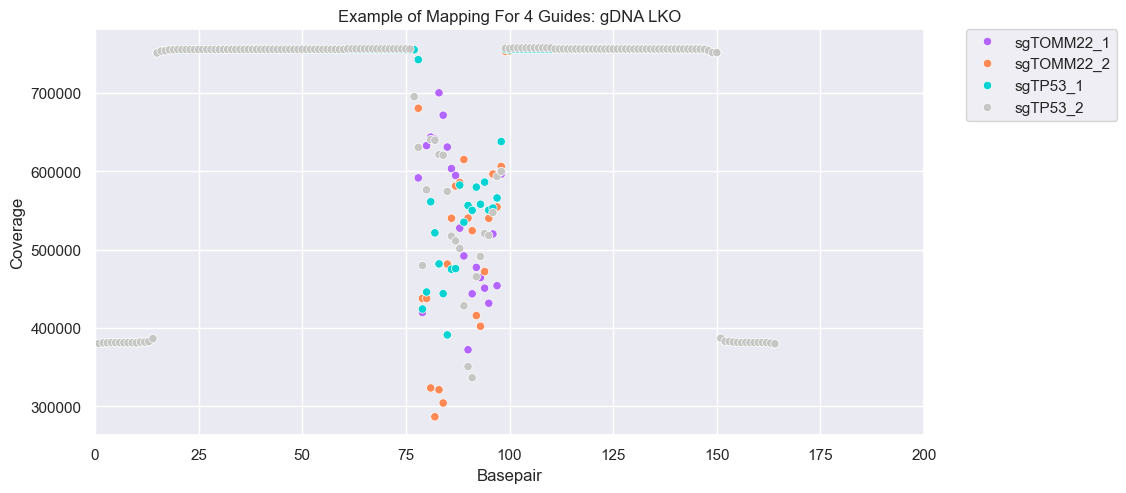

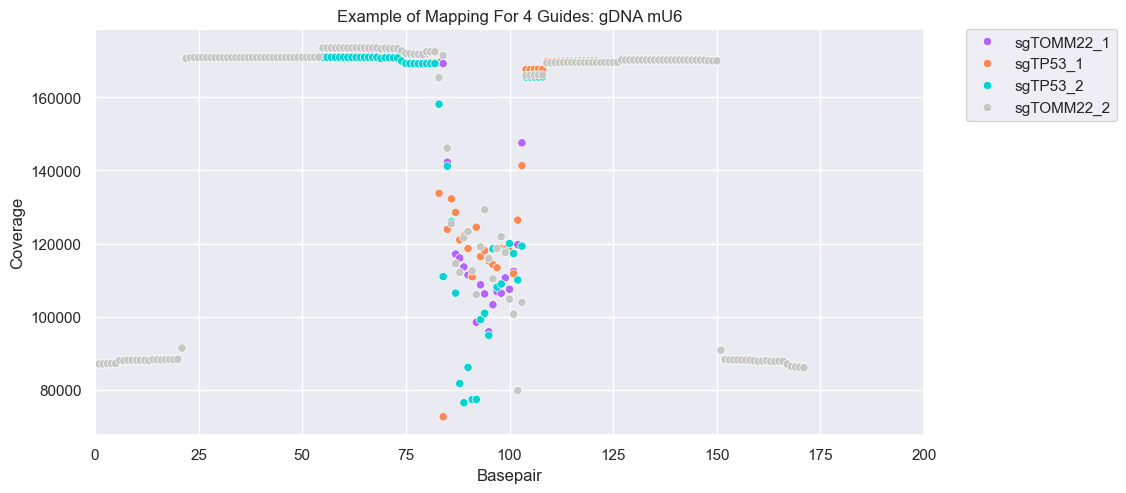

In [3]:
sns.set(rc={'figure.figsize':(10.7,5.27)})

PILOTSTUDY_LIST=["sgTOMM22_1","sgTOMM22_2","sgTP53_1" , "sgTP53_2"]
plot_protospacers(df=PCR_DF, plasmid="LKO", sample="gDNA", pilotstudy_list=PILOTSTUDY_LIST)
plot_protospacers(df=PCR_DF, plasmid="mU6",sample="gDNA", pilotstudy_list=PILOTSTUDY_LIST)

In [4]:
PCR_DF

,Plasmid_FullName,Basepair,Coverage,Filename,Protospacer_type,Protospacer_letter,Protospacer_num,Protospacer,Sample,Plasmid
0,sgTOMM22_1_AB_171,1,87131,gDNA-mU6-704_S4-sgTOMM22_1_AB_171,sgTOMM22,1,AB,sgTOMM22_1,gDNA,mU6
1,sgTOMM22_1_AB_171,2,87170,gDNA-mU6-704_S4-sgTOMM22_1_AB_171,sgTOMM22,1,AB,sgTOMM22_1,gDNA,mU6
2,sgTOMM22_1_AB_171,3,87193,gDNA-mU6-704_S4-sgTOMM22_1_AB_171,sgTOMM22,1,AB,sgTOMM22_1,gDNA,mU6
3,sgTOMM22_1_AB_171,4,87248,gDNA-mU6-704_S4-sgTOMM22_1_AB_171,sgTOMM22,1,AB,sgTOMM22_1,gDNA,mU6
4,sgTOMM22_1_AB_171,5,87263,gDNA-mU6-704_S4-sgTOMM22_1_AB_171,sgTOMM22,1,AB,sgTOMM22_1,gDNA,mU6
...,...,...,...,...,...,...,...,...,...,...
46895,sgALDH1A1_2_CD_164,160,368327,Plasmid-LKO-705_S2-sgALDH1A1_2_CD_164,sgALDH1A1,2,CD,sgALDH1A1_2,Plasmid,LKO
46896,sgALDH1A1_2_CD_164,161,368310,Plasmid-LKO-705_S2-sgALDH1A1_2_CD_164,sgALDH1A1,2,CD,sgALDH1A1_2,Plasmid,LKO
46897,sgALDH1A1_2_CD_164,162,368042,Plasmid-LKO-705_S2-sgALDH1A1_2_CD_164,sgALDH1A1,2,CD,sgALDH1A1_2,Plasmid,LKO
46898,sgALDH1A1_2_CD_164,163,367792,Plasmid-LKO-705_S2-sgALDH1A1_2_CD_164,sgALDH1A1,2,CD,sgALDH1A1_2,Plasmid,LKO


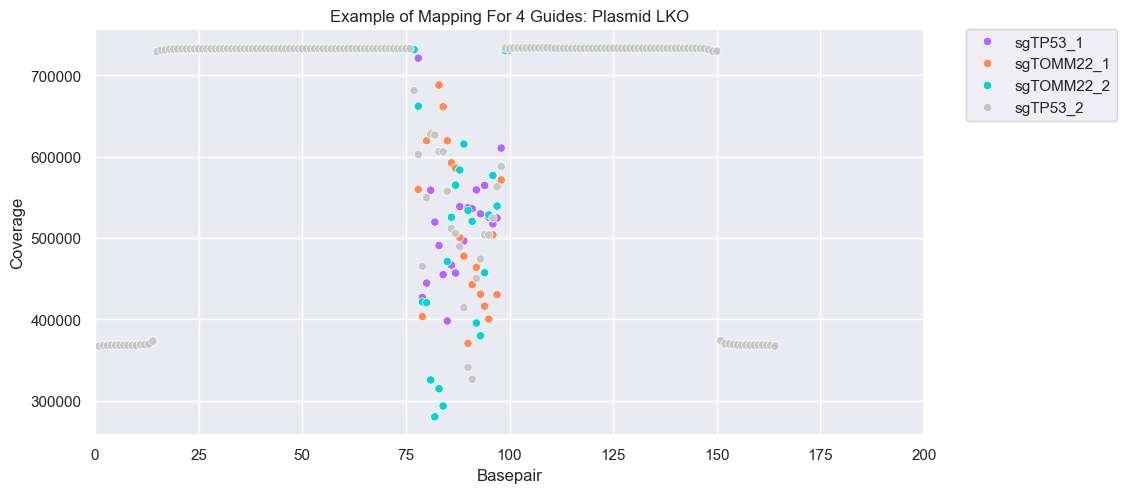

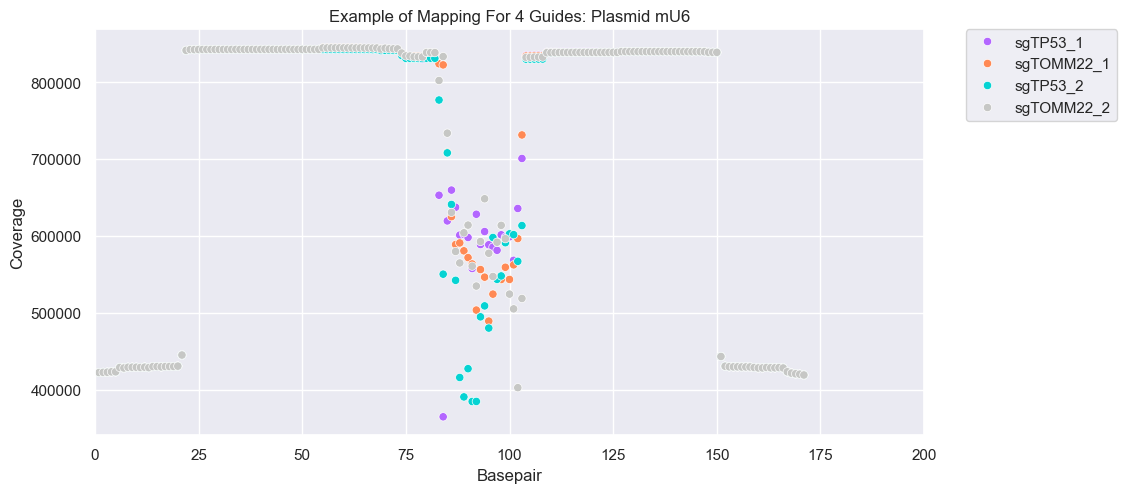

In [5]:
PILOTSTUDY_LIST=["sgTOMM22_1","sgTOMM22_2","sgTP53_1" , "sgTP53_2"]
plot_protospacers(df=PCR_DF, plasmid="LKO", sample="Plasmid", pilotstudy_list=PILOTSTUDY_LIST)
plot_protospacers(df=PCR_DF, plasmid="mU6",sample="Plasmid", pilotstudy_list=PILOTSTUDY_LIST)

For the protospacer analysis, I have selected flags from the bam file that have no mismatch in the sample specific protospacer regions. 

In [8]:

directory = '../COVERAGE/'
# Obtain list of filenames that end in .txt in the directory
all_files = glob.glob(os.path.join(directory, "*.protospacer*coverage"))

#Append them to a df 
your_list = [ ]
for filename in all_files:
    dataframe = pd.read_csv(filename, index_col=None, header=None, sep="\t")
    dataframe["Filename"]=str(filename)
    dataframe["Protospacer_type"]=dataframe["Filename"].str.split("/").str.get(-1).str.split("-").str.get(3).str.split(".").str.get(0).str.split("_").str.get(0)
    dataframe["Protospacer_num"]=dataframe["Filename"].str.split("/").str.get(-1).str.split("-").str.get(3).str.split(".").str.get(0).str.split("_").str.get(1)
    dataframe["Protospacer_letter"]=dataframe["Filename"].str.split("/").str.get(-1).str.split("-").str.get(3).str.split(".").str.get(0).str.split("_").str.get(2)
    dataframe["Protospacer"]=np.where(dataframe["Protospacer_num"]=="negcntrl",dataframe["Protospacer_type"]+"_"+dataframe["Protospacer_letter"]+"_"+dataframe["Protospacer_num"],dataframe["Protospacer_type"]+"_"+dataframe["Protospacer_num"])
    dataframe["Filename"]=dataframe["Filename"].str.split("/").str.get(-1).str.split(".").str.get(0)
    dataframe["Sample"]=dataframe["Filename"].str.split("/").str.get(-1).str.split(".").str.get(0).str.split("-").str.get(0)
    dataframe["Plasmid"]=dataframe["Filename"].str.split("/").str.get(-1).str.split(".").str.get(0).str.split("-").str.get(1)
    your_list.append(dataframe)

PCR_DF_PROTOSPACER=pd.DataFrame(pd.concat(your_list,  ignore_index=True))
PCR_DF_PROTOSPACER.columns =["Plasmid_FullName", "Basepair", "Coverage", "Filename","Protospacer_type" , "Protospacer_letter","Protospacer_num" ,"Protospacer", "Sample","Plasmid"]
print(PCR_DF_PROTOSPACER.head(n=2))

    Plasmid_FullName  Basepair  Coverage                           Filename  \
0  sgTOMM22_2_CD_171         1      4488  gDNA-mU6-704_S4-sgTOMM22_2_CD_171   
1  sgTOMM22_2_CD_171         2      4489  gDNA-mU6-704_S4-sgTOMM22_2_CD_171   

  Protospacer_type Protospacer_letter Protospacer_num Protospacer Sample  \
0         sgTOMM22                  2              CD  sgTOMM22_2   gDNA   
1         sgTOMM22                  2              CD  sgTOMM22_2   gDNA   

  Plasmid  
0     mU6  
1     mU6  


In [10]:
PCR_DF_MED =PCR_DF.groupby(["Sample","Plasmid","Protospacer","Protospacer_type","Protospacer_letter"])[["Coverage"]].median()
PCR_DF_MED.reset_index(level=["Sample","Plasmid","Protospacer","Protospacer_type","Protospacer_letter"], inplace=True)
PCR_DF_MED["Protospacer_type"]=np.where(PCR_DF_MED["Protospacer_letter"].isin(["negcntrl","negativecntrl"]),"negcntrl",PCR_DF_MED["Protospacer_type"])
PCR_DF_PROTOSPACER_FILT=PCR_DF[(PCR_DF["Basepair"]<104) & (PCR_DF["Basepair"]>84) &(PCR_DF["Plasmid"]=="mU6") ]
PCR_DF_PROTOSPACER_FILT_2=PCR_DF[(PCR_DF["Basepair"]<99) & (PCR_DF["Basepair"]>79) &(PCR_DF["Plasmid"]=="LKO") ]
PCR_DF_PROTOSPACER_FILT= pd.concat([PCR_DF_PROTOSPACER_FILT,PCR_DF_PROTOSPACER_FILT_2])
PCR_DF_PROTOSPACER_FILT["Protospacer_type"]=np.where(PCR_DF_PROTOSPACER_FILT["Protospacer_letter"].isin(["negcntrl","negativecntrl","sg"]),"sgnegcntrl",PCR_DF_PROTOSPACER_FILT["Protospacer_type"])

In [11]:
##filter for regions specific for the protospacer sequence 
##full sequence is 171 bp 
##protospacer sequence is 20 bp 1-84-PROT-104-171 (mU6)
###LKO 164bp 1-79-PROT-99-164
PCR_DF_PROTOSPACER_MED =PCR_DF_PROTOSPACER_FILT.groupby(["Sample","Plasmid","Protospacer","Protospacer_type","Protospacer_letter"])[["Coverage"]].median()
PCR_DF_PROTOSPACER_MED.reset_index(level=["Sample","Plasmid","Protospacer","Protospacer_type","Protospacer_letter"], inplace=True)
PCR_DF_PROTOSPACER_MED["Protospacer_type"]=np.where(PCR_DF_PROTOSPACER_MED["Protospacer_letter"].isin(["negcntrl","negativecntrl"]),"negcntrl",PCR_DF_PROTOSPACER_MED["Protospacer_type"])

[Text(0.5, 0, '')]

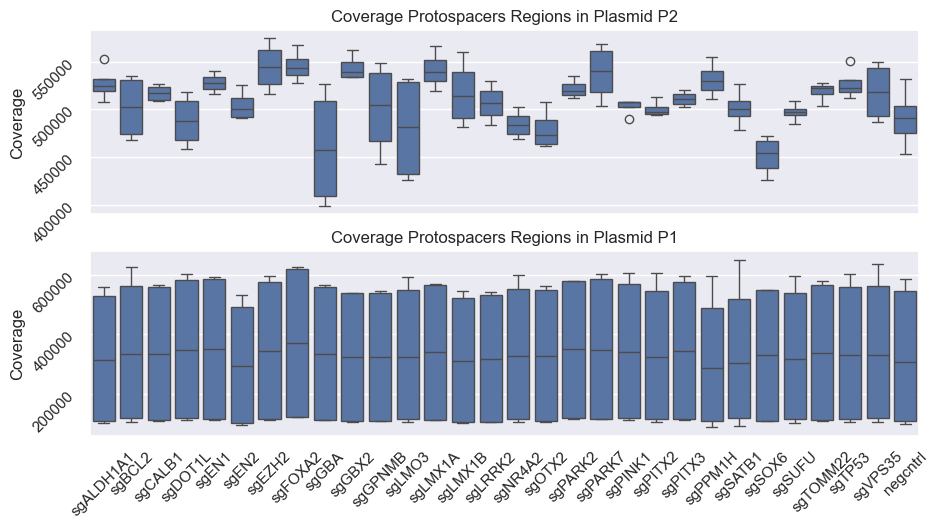

In [12]:
fig, (ax1, ax2) = plt.subplots(2)

PCR_DF_PROTOSPACER_MED_SUB=PCR_DF_PROTOSPACER_FILT[PCR_DF_PROTOSPACER_FILT["Sample"]=="Plasmid"]
sns.boxplot(data=PCR_DF_PROTOSPACER_MED[PCR_DF_PROTOSPACER_MED["Plasmid"]=="LKO"], x="Protospacer_type", y="Coverage",ax=ax1)
sns.boxplot(data=PCR_DF_PROTOSPACER_MED[PCR_DF_PROTOSPACER_MED["Plasmid"]=="mU6"], x="Protospacer_type", y="Coverage",ax=ax2)
ax1.tick_params(labelrotation=45)
ax2.tick_params(labelrotation=45)
ax1.set(xticklabels=[])  # remove the tick labels
ax2.set(title='Coverage Protospacers Regions in Plasmid P1')
ax1.set(title='Coverage Protospacers Regions in Plasmid P2')  # add a title
ax1.set(xlabel=None)  # remove the axis label
ax2.set(xlabel=None)  # remove the axis label
# plt.title("Plasmid")

[Text(0.5, 0, '')]

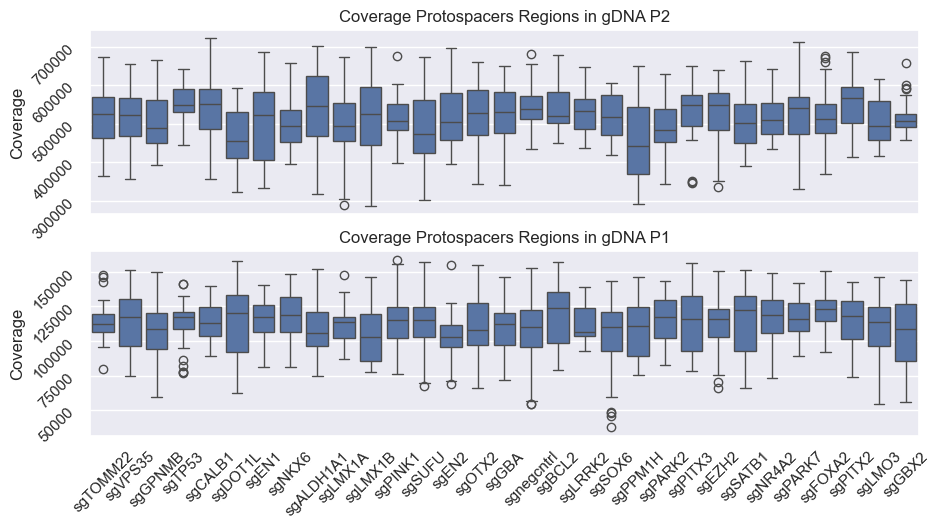

In [13]:
fig, (ax1, ax2) = plt.subplots(2)

PCR_DF_MED_SUB=PCR_DF_PROTOSPACER_FILT[PCR_DF_PROTOSPACER_FILT["Sample"]=="gDNA"]
sns.boxplot(data=PCR_DF_MED_SUB[PCR_DF_MED_SUB["Plasmid"]=="LKO"], x="Protospacer_type", y="Coverage",ax=ax1)
sns.boxplot(data=PCR_DF_MED_SUB[PCR_DF_MED_SUB["Plasmid"]=="mU6"], x="Protospacer_type", y="Coverage",ax=ax2)
ax1.tick_params(labelrotation=45)
ax2.tick_params(labelrotation=45)
ax1.set(xticklabels=[])  # remove the tick labels
ax2.set(title='Coverage Protospacers Regions in gDNA P1')
ax1.set(title='Coverage Protospacers Regions in gDNA P2')  # add a title
ax1.set(xlabel=None)  # remove the axis label
ax2.set(xlabel=None)  # remove the axis label


In [14]:
print("Number of Protospacers with Zero Reads",PCR_DF_MED[PCR_DF_MED["Coverage"]==0].shape[0])
print("Number of Protospacers with only One Read",PCR_DF_MED[PCR_DF_MED["Coverage"]==1].shape[0])
print("Total number of Protospacers across  ",PCR_DF_MED.shape[0])

Number of Protospacers with Zero Reads 0
Number of Protospacers with only One Read 0
Total number of Protospacers across   272


In [15]:
sorted_protospacer_type=PCR_DF_MED[PCR_DF_MED["Sample"]=="Plasmid"].groupby(['Protospacer_type'])['Coverage'].median().sort_values(ascending=False)

In [16]:
dictionary = {'LKO':'Protospacer_2', 'mU6':'Protospacer_1'}
PCR_DF_PROTOSPACER_FILT["Protospacer"]=PCR_DF_PROTOSPACER_FILT["Plasmid"].map(dictionary)

In [17]:
PCR_DF_PROTOSPACER_FILT

,Plasmid_FullName,Basepair,Coverage,Filename,Protospacer_type,Protospacer_letter,Protospacer_num,Protospacer,Sample,Plasmid
84,sgTOMM22_1_AB_171,85,142252,gDNA-mU6-704_S4-sgTOMM22_1_AB_171,sgTOMM22,1,AB,Protospacer_1,gDNA,mU6
85,sgTOMM22_1_AB_171,86,125487,gDNA-mU6-704_S4-sgTOMM22_1_AB_171,sgTOMM22,1,AB,Protospacer_1,gDNA,mU6
86,sgTOMM22_1_AB_171,87,117145,gDNA-mU6-704_S4-sgTOMM22_1_AB_171,sgTOMM22,1,AB,Protospacer_1,gDNA,mU6
87,sgTOMM22_1_AB_171,88,116084,gDNA-mU6-704_S4-sgTOMM22_1_AB_171,sgTOMM22,1,AB,Protospacer_1,gDNA,mU6
88,sgTOMM22_1_AB_171,89,113636,gDNA-mU6-704_S4-sgTOMM22_1_AB_171,sgTOMM22,1,AB,Protospacer_1,gDNA,mU6
...,...,...,...,...,...,...,...,...,...,...
46829,sgALDH1A1_2_CD_164,94,448462,Plasmid-LKO-705_S2-sgALDH1A1_2_CD_164,sgALDH1A1,2,CD,Protospacer_2,Plasmid,LKO
46830,sgALDH1A1_2_CD_164,95,451801,Plasmid-LKO-705_S2-sgALDH1A1_2_CD_164,sgALDH1A1,2,CD,Protospacer_2,Plasmid,LKO
46831,sgALDH1A1_2_CD_164,96,530201,Plasmid-LKO-705_S2-sgALDH1A1_2_CD_164,sgALDH1A1,2,CD,Protospacer_2,Plasmid,LKO
46832,sgALDH1A1_2_CD_164,97,513715,Plasmid-LKO-705_S2-sgALDH1A1_2_CD_164,sgALDH1A1,2,CD,Protospacer_2,Plasmid,LKO


[Text(0, 0.5, '')]

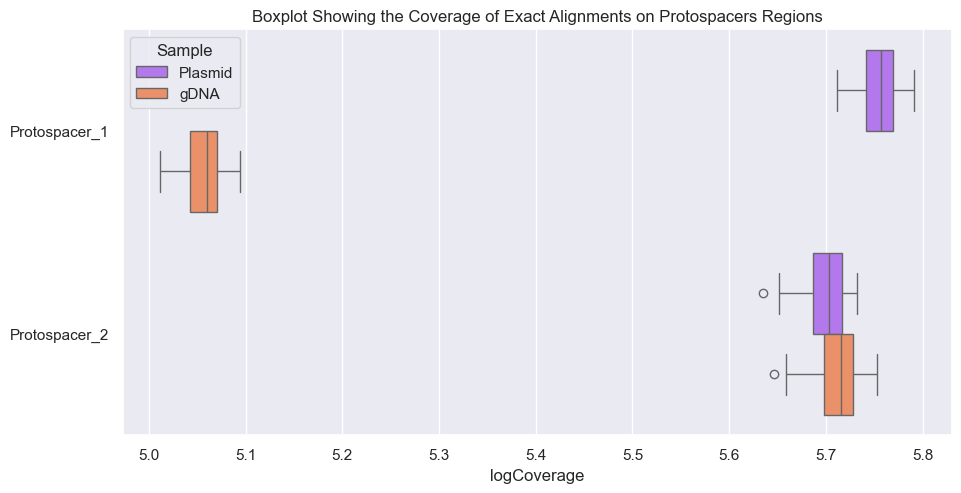

In [18]:
sns.set(rc={'figure.figsize':(10.7,5.27)})
PCR_DF_MED_MED =PCR_DF_PROTOSPACER_FILT.groupby(["Sample","Protospacer","Protospacer_type"])[["Coverage"]].median()
PCR_DF_MED_MED.reset_index(level=["Sample","Protospacer","Protospacer_type"], inplace=True)
PCR_DF_MED_MED["logCoverage"]=np.log10(PCR_DF_MED_MED["Coverage"])
# PCR_DF_MED=PCR_DF_MED[((PCR_DF_MED["Protospacer"]=="protospacerA"))&(PCR_DF_MED["Sample"]!="PCR_220b_S33")]
ax = sns.boxplot(data=PCR_DF_MED_MED, hue="Sample", x="logCoverage", y="Protospacer", palette=palette)

# ax = sns.boxplot(data=PCR_DF_MED_MED, y="Protospacer_type", x="Coverage", hue="Sample",order=sorted_protospacer_type.index)
plt.title("Boxplot Showing the Coverage of Exact Alignments on Protospacers Regions")
# ax.set(yticklabels=[])
ax.set(ylabel=None)
# print("Number of Protospacers with Zero Reads",PCR_DF_MED_MED[PCR_DF_MED_MED["Coverage"]==0].shape[0])
# print("Number of Protospacers with only One Read",PCR_DF_MED_MED[PCR_DF_MED_MED["Coverage"]==1].shape[0])
# print("Total number of Protospacers across  ",PCR_DF_MED_MED.shape[0])